In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import RFE
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
heart = pd.read_csv(r'D:\论文\Anaconda\heartbalance.csv')

In [3]:
heart.head()

,age,gender,BMI,smoke,alcohol,temperature,PR,HR,Respiration,SBP,...,Qi deficiency,Yin deficiency,Blood deficiency,Yang deficiency,heart,liver,spleen,lungs,kidneys,target
0,57,1,27.54,1,1,36.7,123,135,26,175,...,1,0,1,0,1,0,1,0,0,1
1,54,1,25.95,1,1,36.6,140,140,36,186,...,1,0,1,0,1,0,1,0,0,1
2,55,1,24.40,0,0,36.5,83,83,21,129,...,1,0,1,0,1,0,1,0,0,1
3,72,0,24.46,0,0,36.7,95,95,31,122,...,1,0,1,0,1,0,1,0,0,1
4,38,1,36.40,0,0,36.5,116,116,21,161,...,1,0,1,0,1,0,1,0,0,1


In [4]:
# 数据可视化分析 参考前面即可

In [5]:
# 通过相关性进行筛选

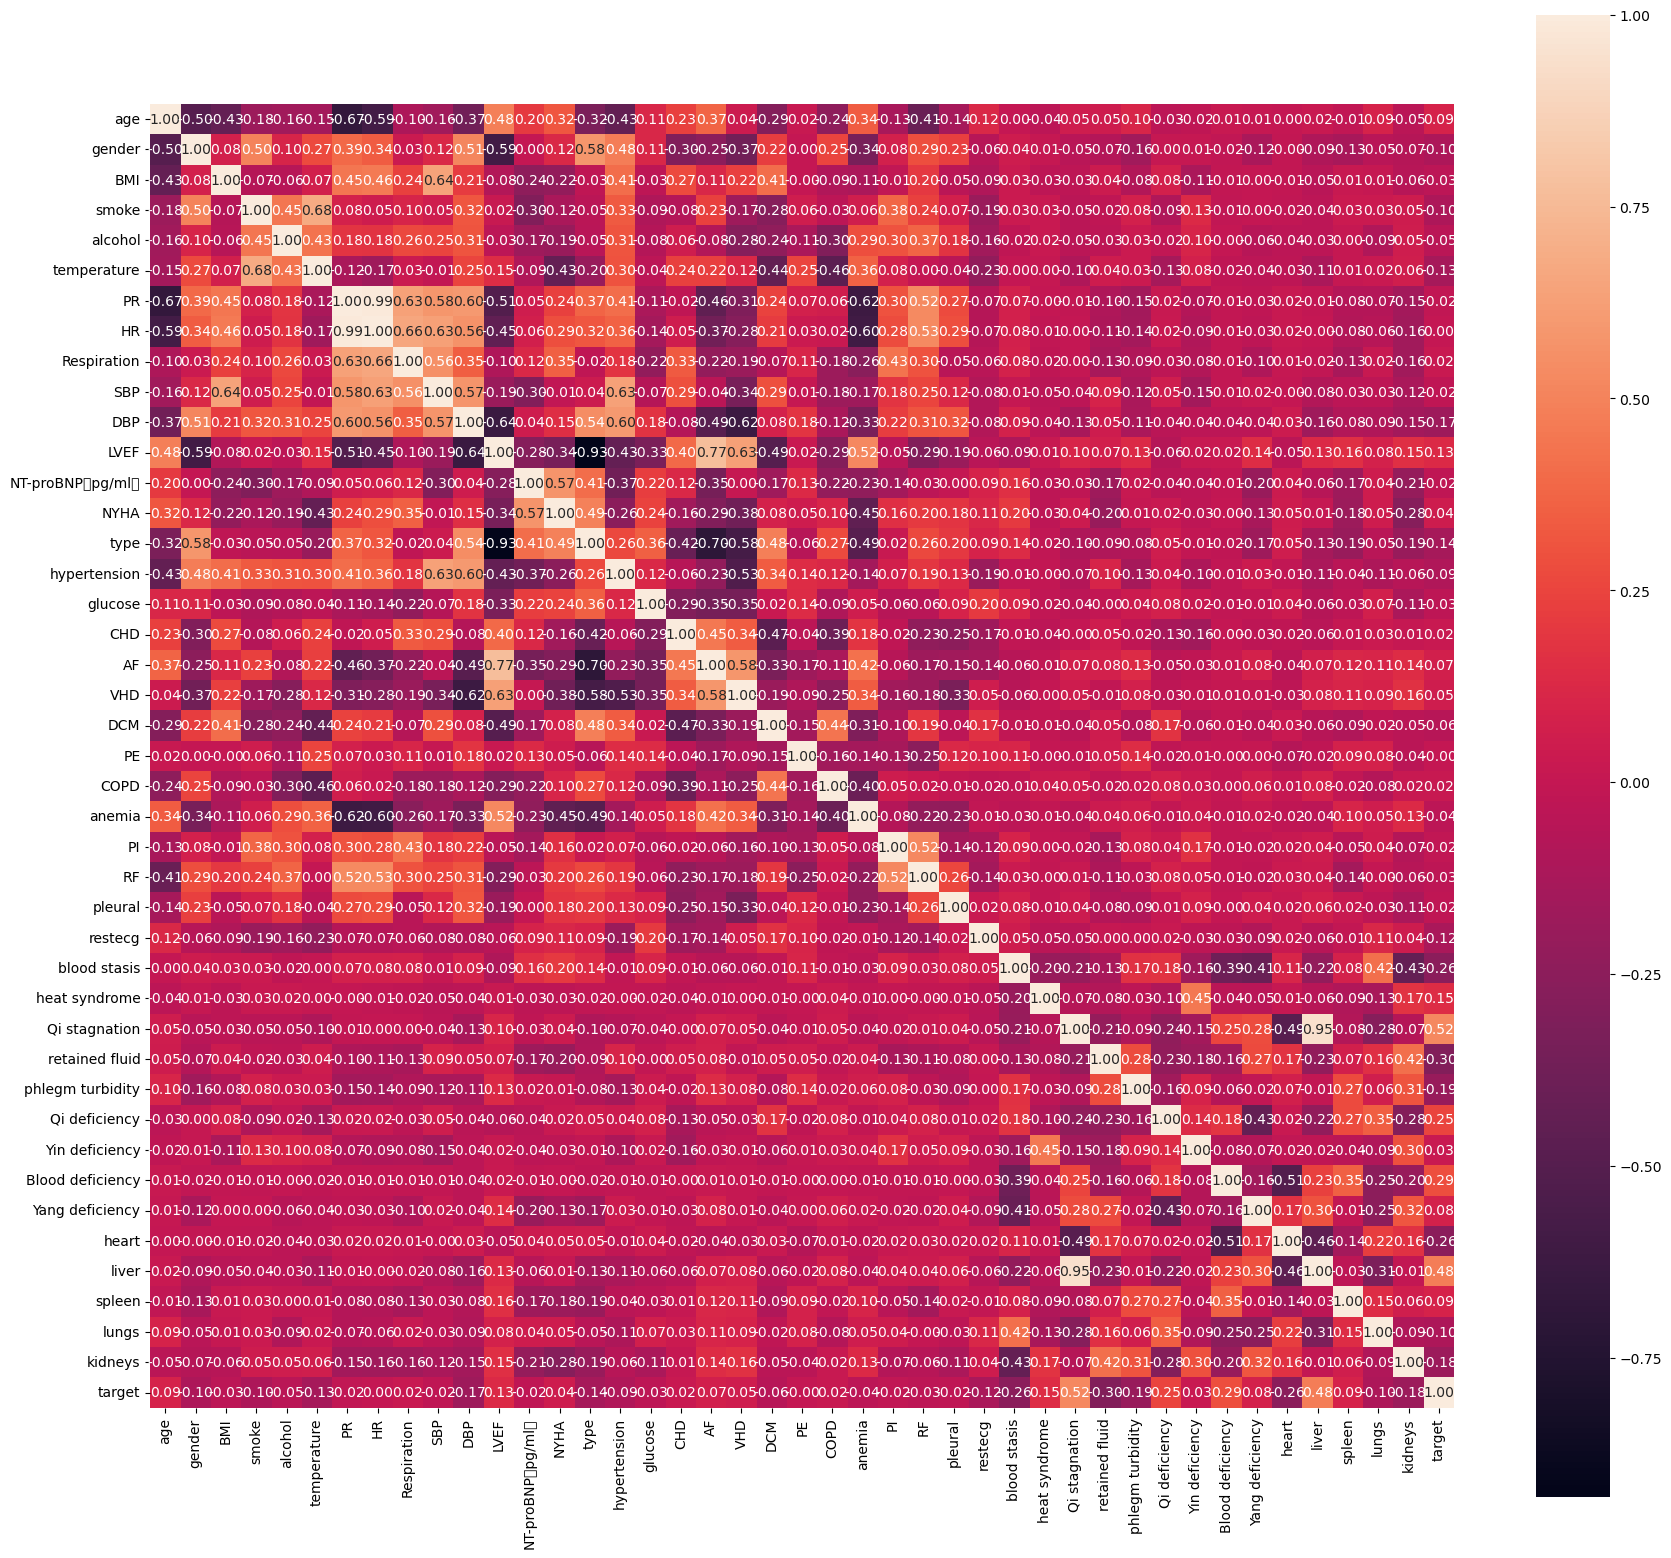

In [6]:
plt.figure(figsize=(18,16))
corr =  heart.corr()
sns.heatmap(data=corr,annot=True, square=True,fmt='.2f')
plt.tight_layout()

In [7]:
### 具有相关性的特征 2个

In [8]:
### 多重共线性

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor 
feature_names = ['age', 'gender', 'BMI','smoke','alcohol', 'temperature', 'PR','HR','Respiration', 'SBP', 'DBP','LVEF','NT-proBNP（pg/ml）',
                 'NYHA','type', 'hypertension', 'glucose', 'CHD','AF','VHD','DCM','PE','COPD','anemia','PI','RF', 'pleural','restecg',
                 'blood stasis','heat syndrome', 'Qi stagnation', 'retained fluid', 'phlegm turbidity','Qi deficiency','Yin deficiency',
                 'Blood deficiency','Yang deficiency','heart','liver','spleen','lungs', 'kidneys']
X=heart[feature_names]
y=heart.target
# 计算 VIF 
vif = pd.Series([variance_inflation_factor(X.values, i) for i in range(X.shape[1])], index=X.columns) 
# 展示VIF结果
index = X.columns.tolist() 
vif_df = pd.DataFrame(vif, index = index, columns = ['vif']).sort_values(by = 'vif', ascending=False) 
vif_df

,vif
PR,17609.908424
HR,15972.363746
SBP,6829.325128
temperature,3757.743457
age,2407.523582
BMI,1557.738364
Respiration,1237.772298
NYHA,930.522809
DBP,654.619353
type,365.600180


In [10]:
# REF（递归特征消除法）

In [11]:
feature_names = ['age', 'gender', 'BMI','smoke','alcohol', 'temperature', 'PR','HR','Respiration', 'SBP', 'DBP','LVEF','NT-proBNP（pg/ml）',
                 'NYHA','type', 'hypertension', 'glucose', 'CHD','AF','VHD','DCM','PE','COPD','anemia','PI','RF', 'pleural','restecg',
                 'blood stasis','heat syndrome', 'Qi stagnation', 'retained fluid', 'phlegm turbidity','Qi deficiency','Yin deficiency',
                 'Blood deficiency','Yang deficiency','heart','liver','spleen','lungs', 'kidneys']

In [12]:
from sklearn import preprocessing
from sklearn.svm import SVC

In [13]:
min_max_scaler1 = preprocessing.MinMaxScaler()
X_train_minmax1 = min_max_scaler1.fit_transform(heart[feature_names])
svc = SVC(kernel="linear")
selector=RFE(estimator=svc, n_features_to_select=10)
Xt=selector.fit_transform(X_train_minmax1,heart.target)
print("N_features %s" % selector.n_features_) 
print("Support is %s" % selector.support_)
print("Ranking %s" % selector.ranking_)
for i in zip(selector.ranking_,feature_names,selector.support_):
    print(i)

N_features 10
Support is [False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False  True  True  True  True False  True  True  True
 False False  True  True False  True]
Ranking [14  8 27 11 19  7  2  3 28  4  5 29 17 13 30 22 23 26 25 33 12 24 16 18
 32  6 15 31  1  1  1  1  9  1  1  1 21 20  1  1 10  1]
(14, 'age', False)
(8, 'gender', False)
(27, 'BMI', False)
(11, 'smoke', False)
(19, 'alcohol', False)
(7, 'temperature', False)
(2, 'PR', False)
(3, 'HR', False)
(28, 'Respiration', False)
(4, 'SBP', False)
(5, 'DBP', False)
(29, 'LVEF', False)
(17, 'NT-proBNP（pg/ml）', False)
(13, 'NYHA', False)
(30, 'type', False)
(22, 'hypertension', False)
(23, 'glucose', False)
(26, 'CHD', False)
(25, 'AF', False)
(33, 'VHD', False)
(12, 'DCM', False)
(24, 'PE', False)
(16, 'COPD', False)
(18, 'anemia', False)
(32, 'PI', False)
(6, 'RF', False)
(15, 'pleural', False)
(31, 'restecg', Fal

In [14]:
# 正则化

In [15]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel
X=heart[feature_names]
y=heart.target

In [16]:
model = LinearSVC(penalty= 'l1', C = 0.1,dual=False)
model.fit(X,y) 
selector = SelectFromModel(estimator = model, prefit=True,max_features=10)
X_new = selector.transform(X)
feature_names = np.array(X.columns) 
feature_names[selector.get_support()]

array(['DCM', 'RF', 'blood stasis', 'heat syndrome', 'Qi stagnation',
       'Qi deficiency', 'Yang deficiency', 'liver', 'spleen', 'kidneys'],
      dtype=object)

In [17]:
# 模型建立与评价

In [18]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

In [19]:
select_features=[ 'blood stasis', 'heat syndrome', 'Qi stagnation',
       'Qi deficiency', 'liver', 'spleen', 'kidneys']

In [20]:
X1 = heart[select_features]
y1 = heart.target
train_X, val_X, train_y, val_y = train_test_split(X1, y1, test_size= 0.30, random_state= 42)

In [21]:
# 模型建立

In [22]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn import tree
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

In [24]:
# 逻辑回归

In [25]:
model_logistics = LogisticRegression(class_weight='balanced')
model_logistics.fit(train_X,train_y)
y_pred = model_logistics.predict(val_X)
scores_logistics=[]
scores_logistics.append(precision_score(val_y, y_pred))
scores_logistics.append(recall_score(val_y, y_pred))
confusion_matrix_logistics=confusion_matrix(val_y,y_pred)
f1_score_logistics=f1_score(val_y, y_pred,labels=None, pos_label=1, average='binary', sample_weight=None)
precision_logistics = precision_score(val_y, y_pred, average='binary')
importance=pd.DataFrame({"columns":list(val_X.columns), "coef":list(model_logistics.coef_.T)})
predictions_log=model_logistics.predict_proba(val_X)
FPR_log, recall_log, thresholds = roc_curve(val_y, predictions_log[:,1],pos_label=1)
area_log=auc(FPR_log,recall_log)

In [26]:
print('logistics模型结果：\n')
print(pd.DataFrame(columns=['预测值=1','预测值=0'],index=['真实值=1','真实值=0'],data=confusion_matrix_logistics))
print("f1值:"+str(f1_score_logistics))
print("准确率和召回率为："+str(scores_logistics))
print('模型系数：\n'+str(importance))

logistics模型结果：

       预测值=1  预测值=0
真实值=1    467     24
真实值=0     62    475
f1值:0.916988416988417
准确率和召回率为：[0.9519038076152304, 0.8845437616387337]
模型系数：
         columns                   coef
0   blood stasis    [-4.58379655232134]
1  heat syndrome    [4.301860816125317]
2  Qi stagnation     [8.58789679189453]
3  Qi deficiency   [3.1188864619577013]
4          liver  [-1.8326550371188353]
5         spleen    [1.288081114846471]
6        kidneys   [-3.364201615068894]


0.9163424124513618

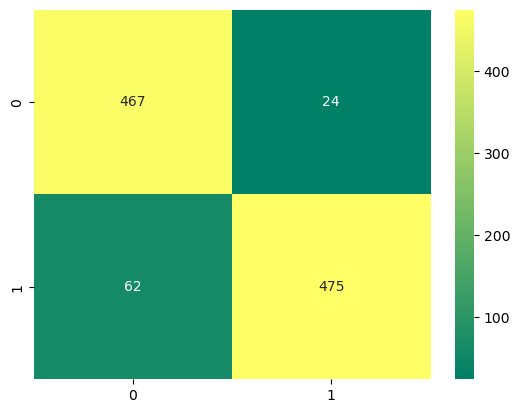

In [27]:
#混淆矩阵
mat = confusion_matrix(val_y, y_pred)
p = sns.heatmap(pd.DataFrame(mat), annot=True, cmap="summer" ,fmt='g')
accuracy_score(val_y, y_pred)

In [28]:
# SVM模型建立

In [29]:
from sklearn.svm import SVC

In [30]:
min_max_scaler = preprocessing.MinMaxScaler()
X_train_minmax = min_max_scaler.fit_transform(train_X)
X_test_minmax=min_max_scaler.transform(val_X)

In [31]:
model_svm=SVC(class_weight='balanced')
model_svm.fit(X_train_minmax,train_y)

SVC(class_weight='balanced')

In [32]:
y_pred = model_svm.predict(X_test_minmax)

In [33]:
scores_svm=[]
scores_svm.append(precision_score(val_y, y_pred))
scores_svm.append(recall_score(val_y, y_pred))

In [34]:
confusion_matrix_svm=confusion_matrix(val_y,y_pred)

In [35]:
f1_score_svm=f1_score(val_y, y_pred,labels=None, pos_label=1, average='binary', sample_weight=None)

In [36]:
predictions_svm=model_svm.decision_function(X_test_minmax)

In [37]:
FPR_svm, recall_svm, thresholds = roc_curve(val_y,predictions_svm[:], pos_label=1)

In [38]:
area_svm = auc(FPR_svm,recall_svm)

In [39]:
print('svm模型结果：\n')
print(pd.DataFrame(columns=['预测值=1','预测值=0'],index=['真实值=1','真实值=0'],data=confusion_matrix_svm))
print("f1值:"+str(f1_score_svm))
print("准确率和召回率为："+str(scores_svm))

svm模型结果：

       预测值=1  预测值=0
真实值=1    479     12
真实值=0     64    473
f1值:0.9256360078277887
准确率和召回率为：[0.9752577319587629, 0.8808193668528864]


0.9260700389105059

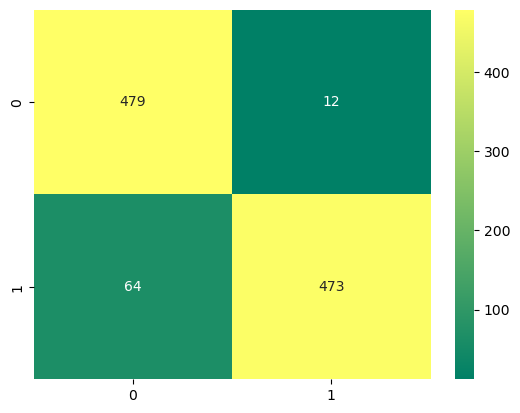

In [40]:
#混淆矩阵
mat = confusion_matrix(val_y, y_pred)
p = sns.heatmap(pd.DataFrame(mat), annot=True, cmap="summer" ,fmt='g')
accuracy_score(val_y, y_pred)

In [41]:
# XGBoost

In [42]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

In [43]:
train_X, val_X, train_y, val_y = train_test_split(X1, y1, test_size= 0.30, random_state= 42)

In [44]:
scale_pos_weight = sum(train_y == 0) / sum(train_y == 1)

In [45]:
params = {
    'objective': 'binary:logistic',
    'scale_pos_weight': scale_pos_weight,
    'max_delta_step': 1,
    'eval_metric': 'auc',
    'eta': 0.1,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

In [46]:
dtrain = xgb.DMatrix(train_X, label=train_y)
dtest = xgb.DMatrix(val_X, label=val_y)

In [47]:
bst = xgb.train(params, dtrain, num_boost_round=100)

In [48]:
y_pred = bst.predict(dtest)
y_pred_binary = [1 if p > 0.5 else 0 for p in y_pred]

In [49]:
print(classification_report(val_y, y_pred_binary))
print("AUC-ROC:", roc_auc_score(val_y, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       491
           1       0.98      0.88      0.93       537

    accuracy                           0.93      1028
   macro avg       0.93      0.93      0.93      1028
weighted avg       0.93      0.93      0.93      1028

AUC-ROC: 0.97513340691099


In [50]:
####

In [51]:
from xgboost.sklearn import XGBClassifier
model_XGB = XGBClassifier().fit(train_X, train_y)
model_XGB

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [52]:
y_pred = model_XGB.predict(val_X)

In [53]:
scores_XGB=[]
scores_XGB.append(precision_score(val_y, y_pred))
scores_XGB.append(recall_score(val_y, y_pred))
confusion_matrix_XGB=confusion_matrix(val_y,y_pred)
f1_score_XGB=f1_score(val_y, y_pred,labels=None, pos_label=0, average="binary", sample_weight=None)

In [54]:
predictions_xgb=model_XGB.predict_proba(val_X)
FPR_xgb, recall_xgb, thresholds = roc_curve(val_y,predictions_xgb[:,1], pos_label=1)
area_xgb = auc(FPR_xgb,recall_xgb)

In [55]:
print('xgboost模型结果：\n')
print(pd.DataFrame(columns=['预测值=1','预测值=0'],index=['真实值=1','真实值=0'],data=confusion_matrix_XGB))
print("f1值:"+str(f1_score_XGB))
print("精确度和召回率:"+str(scores_XGB))

xgboost模型结果：

       预测值=1  预测值=0
真实值=1    479     12
真实值=0     63    474
f1值:0.9273959341723137
精确度和召回率:[0.9753086419753086, 0.88268156424581]


0.9270428015564203

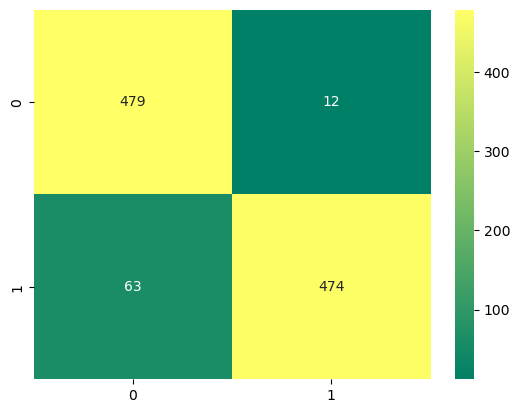

In [56]:
#混淆矩阵
mat = confusion_matrix(val_y, y_pred)
p = sns.heatmap(pd.DataFrame(mat), annot=True, cmap="summer" ,fmt='g')
accuracy_score(val_y, y_pred)

In [57]:
#ROC图的绘制

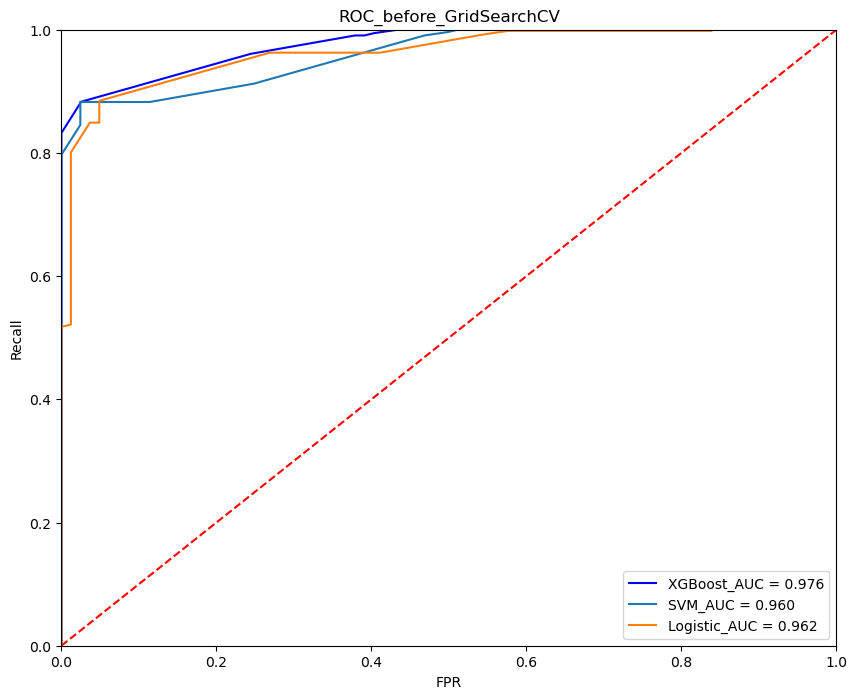

In [58]:
plt.figure(figsize=(10,8))
plt.plot(FPR_xgb, recall_xgb, 'b', label='XGBoost_AUC = %0.3f' % area_xgb)
plt.plot(FPR_svm, recall_svm,label='SVM_AUC = %0.3f' % area_svm)
plt.plot(FPR_log, recall_log,label='Logistic_AUC = %0.3f' % area_log)
plt.legend(loc='lower right')
plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.ylabel('Recall')
plt.xlabel('FPR')
plt.title('ROC_before_GridSearchCV')
plt.show()

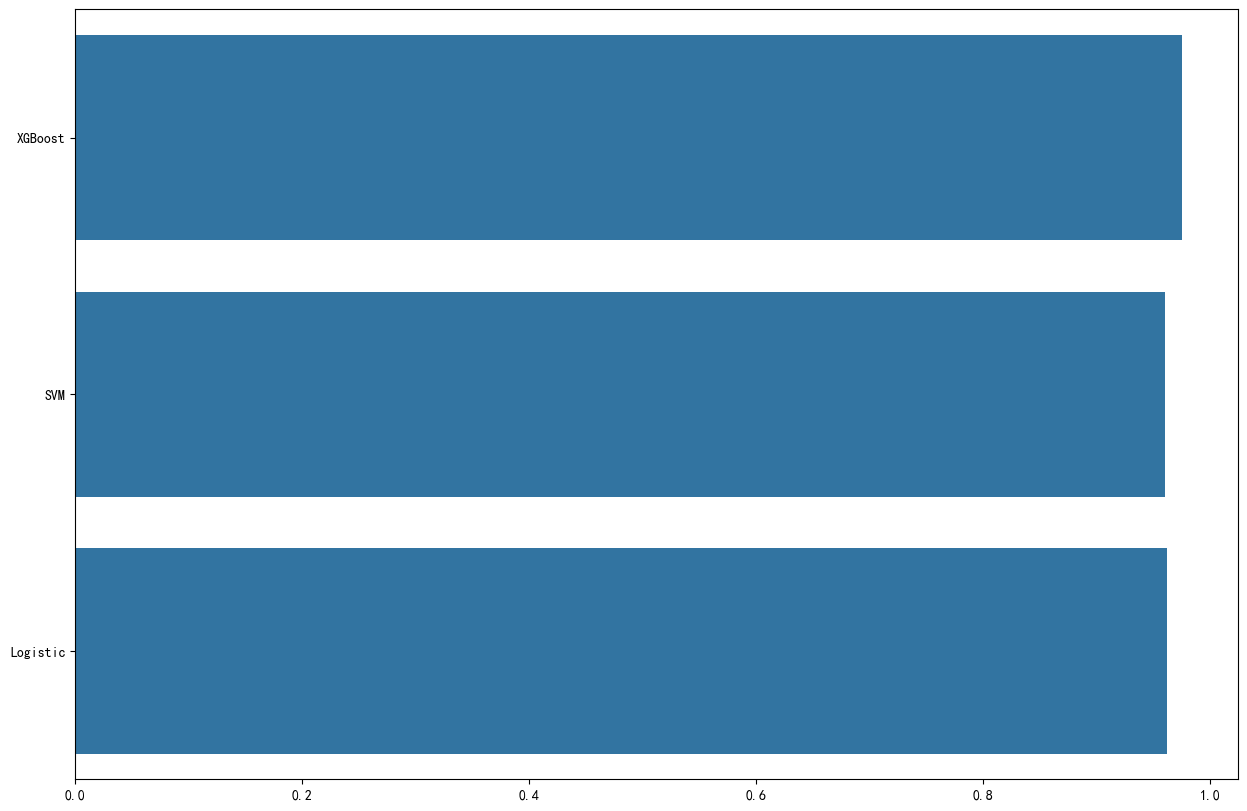

In [59]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei']
import seaborn as sns
model = ['XGBoost','SVM','Logistic']
score = [area_xgb, area_svm, area_log]
plt.figure(figsize = (15, 10))
sns.barplot(x = score, y = model)
plt.show()

In [60]:
### 绘制逻辑回归、SVM和XGB的混淆矩阵 

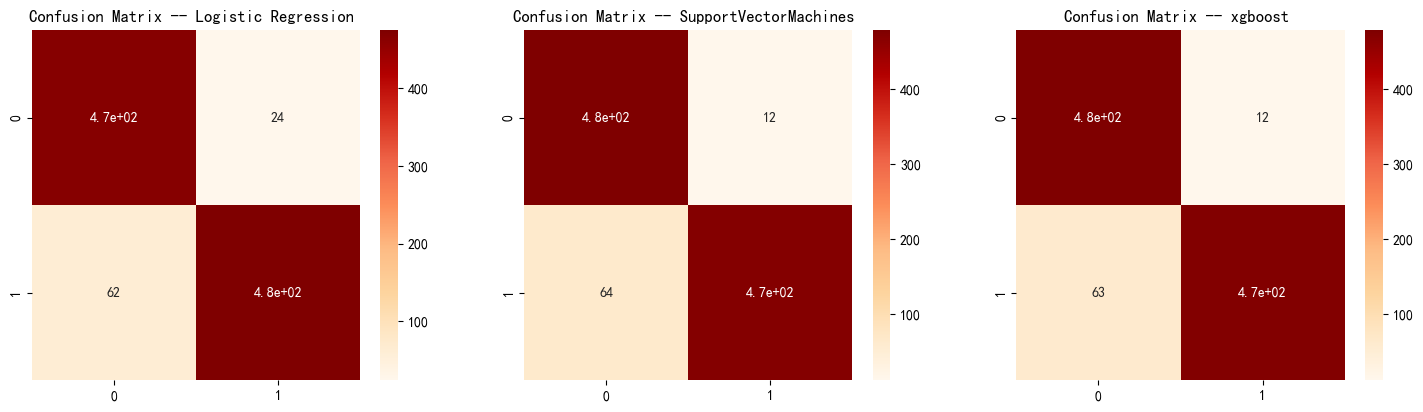

In [61]:
from sklearn.metrics import confusion_matrix
i=1
fig1= plt.figure(figsize=(3*6,2*5))
 
estimator_dict={'Logistic Regression':model_logistics,'SupportVectorMachines':model_svm,'xgboost':model_XGB}
for key,estimator in estimator_dict.items():
    # 绘制混淆矩阵
    pred_y =  estimator.predict(val_X)
    matrix = pd.DataFrame(confusion_matrix(val_y,pred_y))
    ax1 = fig1.add_subplot(2,3,i)
    sns.heatmap(matrix,annot=True,cmap='OrRd')
    plt.title('Confusion Matrix -- %s ' % key)
    i+=1
plt.show()

In [62]:
### shap可视化

In [63]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [64]:
import shap